<a href="https://colab.research.google.com/github/anshsaboo/financial-fraud-detection/blob/dataset/isolation_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Top 10 anomalies:
       TransactionAmount Channel  CustomerAge CustomerOccupation  \
394                6.30  Branch           80            Retired   
1213            1192.20  Branch           60            Retired   
1557             262.43  Online           37             Doctor   
772              827.14  Branch           36           Engineer   
274             1176.28     ATM           54           Engineer   
463              302.16  Online           80            Retired   
1057              83.07  Branch           27           Engineer   
2053              58.32  Branch           29           Engineer   
2310             176.52  Online           73            Retired   
898             1531.31  Online           18            Student   

      AccountBalance  LoginAttempts  TransactionDuration  Anomaly  \
394          7697.68              5                  283       -1   
1213         7816.41              5                  103       -1   
1557        12841.01              5 

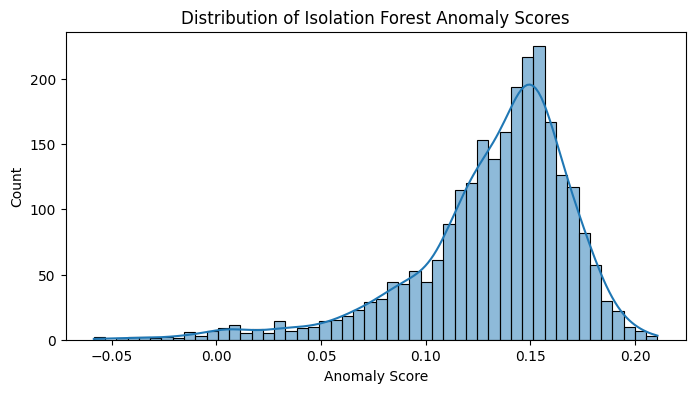

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
url = "https://raw.githubusercontent.com/anshsaboo/financial-fraud-detection/refs/heads/dataset/bank_transactions_data_2.csv"
df = pd.read_csv(url)

# Select relevant features (without IDs or post-transaction dependent fields)
features = [
    'TransactionAmount',
    'Channel',
    'CustomerAge',
    'CustomerOccupation',
    'AccountBalance',
    'LoginAttempts',
    'TransactionDuration',
]

df = df[features].dropna()

# Define columns by type
categorical_feats = ['Channel', 'CustomerOccupation']
numerical_feats   = [
    'TransactionAmount', 'CustomerAge', 'AccountBalance', 'LoginAttempts', 'TransactionDuration'
]

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_feats),
        ('cat', OneHotEncoder(drop='first'), categorical_feats),
    ]
)

# Model pipeline
model = Pipeline([
    ('preprocessor', preprocessor),
    ('isoforest', IsolationForest(
        n_estimators=100,
        contamination=0.01,   # Set expected anomaly rate, adjust as required
        random_state=42
    ))
])

# Fit the model
model.fit(df)

# Predict anomaly labels and get anomaly scores
X_transformed = model.named_steps['preprocessor'].transform(df)
anom_labels = model.named_steps['isoforest'].predict(X_transformed)
anom_scores = model.named_steps['isoforest'].decision_function(X_transformed)

# Attach results to the dataframe
df['Anomaly'] = anom_labels
df['AnomalyScore'] = anom_scores

# View, save, and print detected anomalies
anomalies = df[df['Anomaly'] == -1].copy().sort_values('AnomalyScore')
print("Top 10 anomalies:\n", anomalies.head(10))

# Save the anomalies to a CSV file
anomalies.to_csv('anomalous_transactions.csv', index=False)

# Optional: visualize the anomaly scores distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['AnomalyScore'], bins=50, kde=True)
plt.title('Distribution of Isolation Forest Anomaly Scores')
plt.xlabel('Anomaly Score')
plt.show()